In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import matplotlib.pyplot as plt
import numpy as np

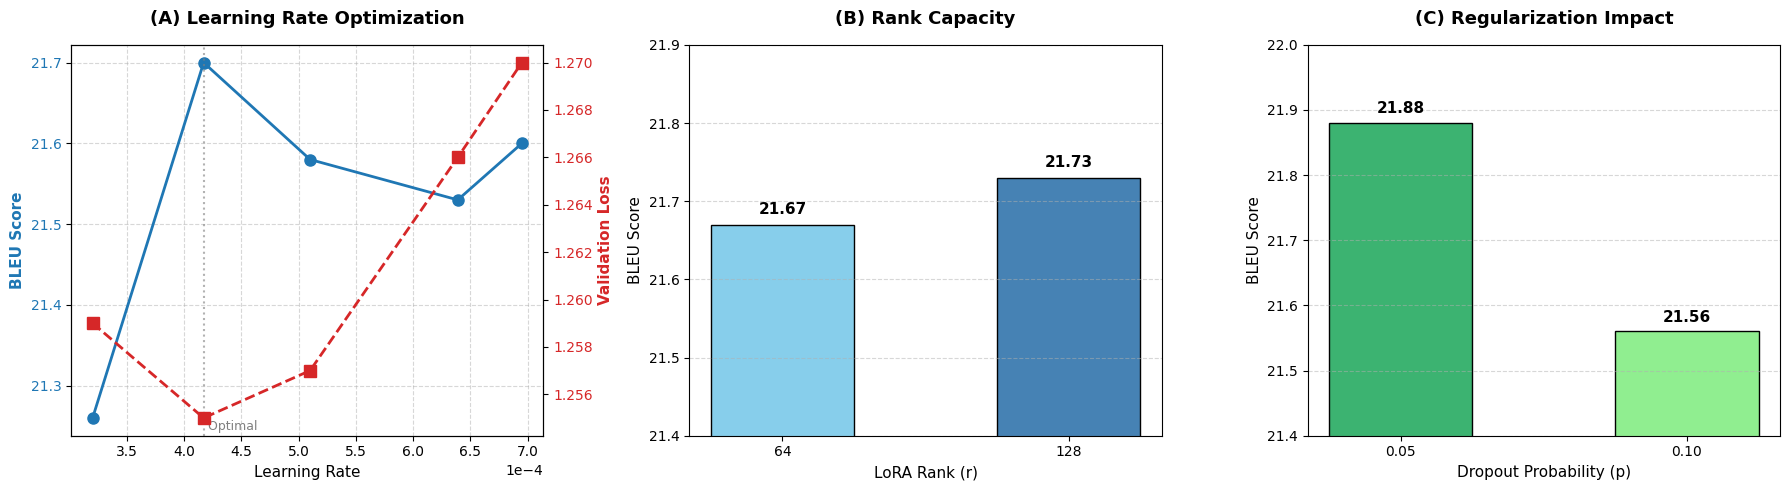

In [3]:
def plot_ablation_summary():
    """
    Generates a 3-panel figure summarizing Learning Rate, Rank, and Dropout ablation studies.
    """

    # --- Data Entry ---
    # 1. Learning Rate Data
    lr_values = [3.20e-4, 4.17e-4, 5.10e-4, 6.39e-4, 6.95e-4]
    lr_bleu =   [21.26,   21.70,   21.58,   21.53,   21.60]
    lr_loss =   [1.259,   1.255,   1.257,   1.266,   1.270]

    # 2. Rank Data
    rank_labels = ['64', '128']
    rank_bleu = [21.67, 21.73]

    # 3. Dropout Data
    dropout_labels = ['0.05', '0.10']
    dropout_bleu = [21.88, 21.56]

    # --- Plotting Configuration ---
    # Create a figure with 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=0.3)

    # ==========================================
    # Plot 1: Learning Rate Sensitivity (Dual Axis)
    # ==========================================
    ax1 = axes[0]
    color_bleu = '#1f77b4' # Tab:blue
    color_loss = '#d62728' # Tab:red

    # X-Axis setup
    ax1.set_xlabel('Learning Rate', fontsize=11)
    ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # Scientific notation

    # Left Y-Axis (BLEU)
    ax1.set_ylabel('BLEU Score', color=color_bleu, fontweight='bold', fontsize=11)
    ax1.plot(lr_values, lr_bleu, color=color_bleu, marker='o', label='BLEU', linewidth=2, markersize=8)
    ax1.tick_params(axis='y', labelcolor=color_bleu)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Right Y-Axis (Loss)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Loss', color=color_loss, fontweight='bold', fontsize=11)
    ax2.plot(lr_values, lr_loss, color=color_loss, marker='s', linestyle='--', label='Val Loss', linewidth=2, markersize=8)
    ax2.tick_params(axis='y', labelcolor=color_loss)

    # Title & Highlights
    ax1.set_title('(A) Learning Rate Optimization', fontsize=13, fontweight='bold', pad=15)
    # Highlight the optimal point (4.17e-4)
    ax1.axvline(x=4.17e-4, color='gray', linestyle=':', alpha=0.6)
    ax1.text(4.17e-4, 21.25, ' Optimal', color='gray', fontsize=9, verticalalignment='center')


    # ==========================================
    # Plot 2: Rank Ablation (Bar Chart)
    # ==========================================
    ax3 = axes[1]
    bars_rank = ax3.bar(rank_labels, rank_bleu, color=['#87CEEB', '#4682B4'], width=0.5, edgecolor='black')

    ax3.set_ylabel('BLEU Score', fontsize=11)
    ax3.set_xlabel('LoRA Rank (r)', fontsize=11)
    ax3.set_title('(B) Rank Capacity', fontsize=13, fontweight='bold', pad=15)

    # Zoom in Y-axis to show the marginal difference clearly
    ax3.set_ylim(21.4, 21.9)
    ax3.grid(axis='y', linestyle='--', alpha=0.5)

    # Add value labels on top of bars
    for bar in bars_rank:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')


    # ==========================================
    # Plot 3: Dropout Ablation (Bar Chart)
    # ==========================================
    ax4 = axes[2]
    bars_drop = ax4.bar(dropout_labels, dropout_bleu, color=['#3CB371', '#90EE90'], width=0.5, edgecolor='black')

    ax4.set_ylabel('BLEU Score', fontsize=11)
    ax4.set_xlabel('Dropout Probability (p)', fontsize=11)
    ax4.set_title('(C) Regularization Impact', fontsize=13, fontweight='bold', pad=15)

    # Zoom in Y-axis
    ax4.set_ylim(21.4, 22.0)
    ax4.grid(axis='y', linestyle='--', alpha=0.5)

    # Add value labels
    for bar in bars_drop:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # --- Final Layout ---
    plt.tight_layout()

    # Save the figure
    plt.savefig('/content/drive/MyDrive/Research_Paper_Publication/plots/ablation_study_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the function
plot_ablation_summary()

## Analyzing computational cost (time)

In [4]:
import pandas as pd
from matplotlib.lines import Line2D

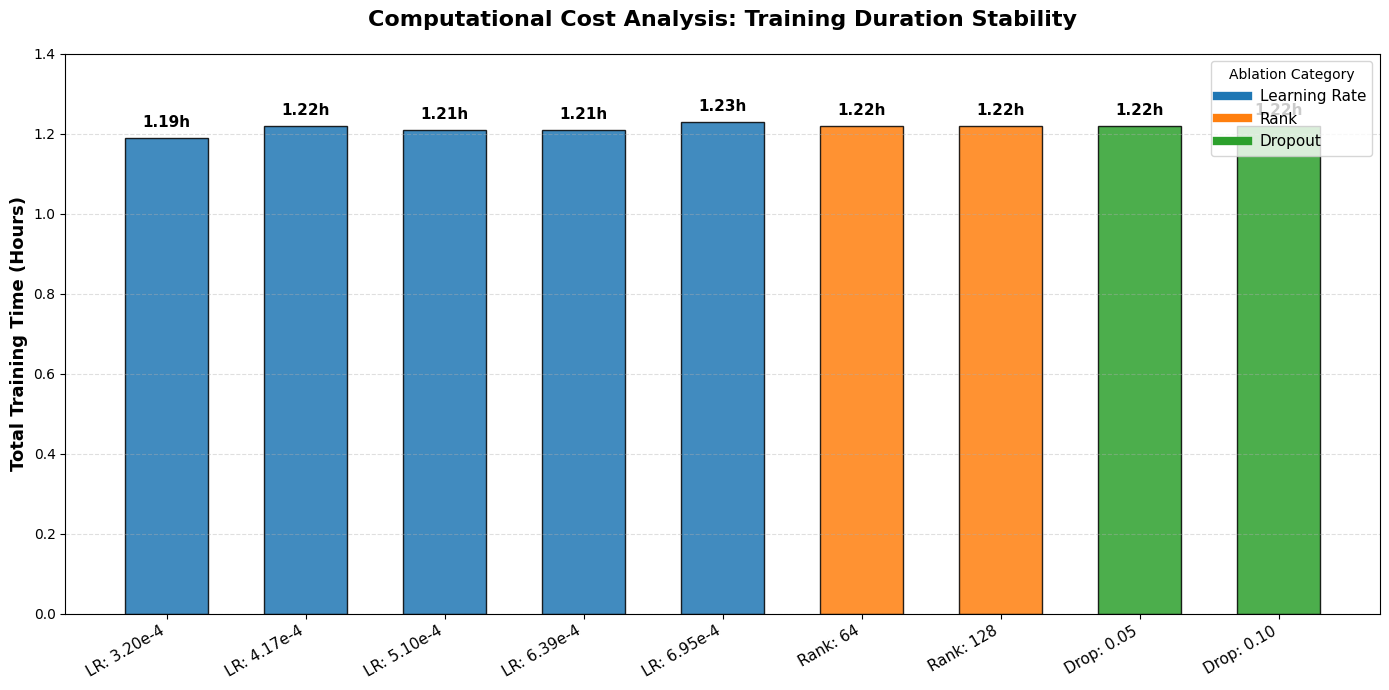

In [5]:
def plot_time_ablation():
    """
    Generates a bar chart comparing the total training time (in Hours)
    across all ablation studies (LR, Rank, Dropout).
    """

    # --- Data Construction ---
    # Manually parsing the "Time Taken" logs from your provided output
    data = [
        # Learning Rate Experiments
        {"Category": "Learning Rate", "Parameter": "LR: 3.20e-4", "Time_Hours": 1.19}, # 1:11:29
        {"Category": "Learning Rate", "Parameter": "LR: 4.17e-4", "Time_Hours": 1.22}, # 1:12:59
        {"Category": "Learning Rate", "Parameter": "LR: 5.10e-4", "Time_Hours": 1.21}, # 1:12:45
        {"Category": "Learning Rate", "Parameter": "LR: 6.39e-4", "Time_Hours": 1.21}, # 1:12:38
        {"Category": "Learning Rate", "Parameter": "LR: 6.95e-4", "Time_Hours": 1.23}, # 1:13:32

        # Rank Experiments
        {"Category": "Rank", "Parameter": "Rank: 64",  "Time_Hours": 1.22}, # 1:13:12
        {"Category": "Rank", "Parameter": "Rank: 128", "Time_Hours": 1.22}, # 1:13:10

        # Dropout Experiments
        {"Category": "Dropout", "Parameter": "Drop: 0.05", "Time_Hours": 1.22}, # 1:13:23
        {"Category": "Dropout", "Parameter": "Drop: 0.10", "Time_Hours": 1.22}, # 1:13:10
    ]

    df = pd.DataFrame(data)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(14, 7))

    # Color mapping for clarity
    colors = {'Learning Rate': '#1f77b4', 'Rank': '#ff7f0e', 'Dropout': '#2ca02c'}
    bar_colors = df['Category'].map(colors)

    # Create Bar Chart
    bars = ax.bar(df['Parameter'], df['Time_Hours'], color=bar_colors, alpha=0.85, edgecolor='black', width=0.6)

    # --- Formatting ---
    ax.set_ylabel("Total Training Time (Hours)", fontsize=13, fontweight='bold')
    ax.set_title("Computational Cost Analysis: Training Duration Stability", fontsize=16, fontweight='bold', pad=20)

    # Zoom in to highlight the consistency (or lack thereof)
    # Lower bound 1.15 to make the small differences visible, Upper bound 1.30
    ax.set_ylim(0, 1.4)

    # Add grid
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # --- Legend ---
    custom_lines = [Line2D([0], [0], color=c, lw=6) for c in colors.values()]
    ax.legend(custom_lines, colors.keys(), title="Ablation Category", fontsize=11, loc='upper right')

    # --- Annotations ---
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}h',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # X-axis ticks
    plt.xticks(rotation=30, ha='right', fontsize=11)

    # Final Layout
    plt.tight_layout()

    # Save
    plt.savefig('/content/drive/MyDrive/Research_Paper_Publication/plots/ablation_time_cost.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run
plot_time_ablation()

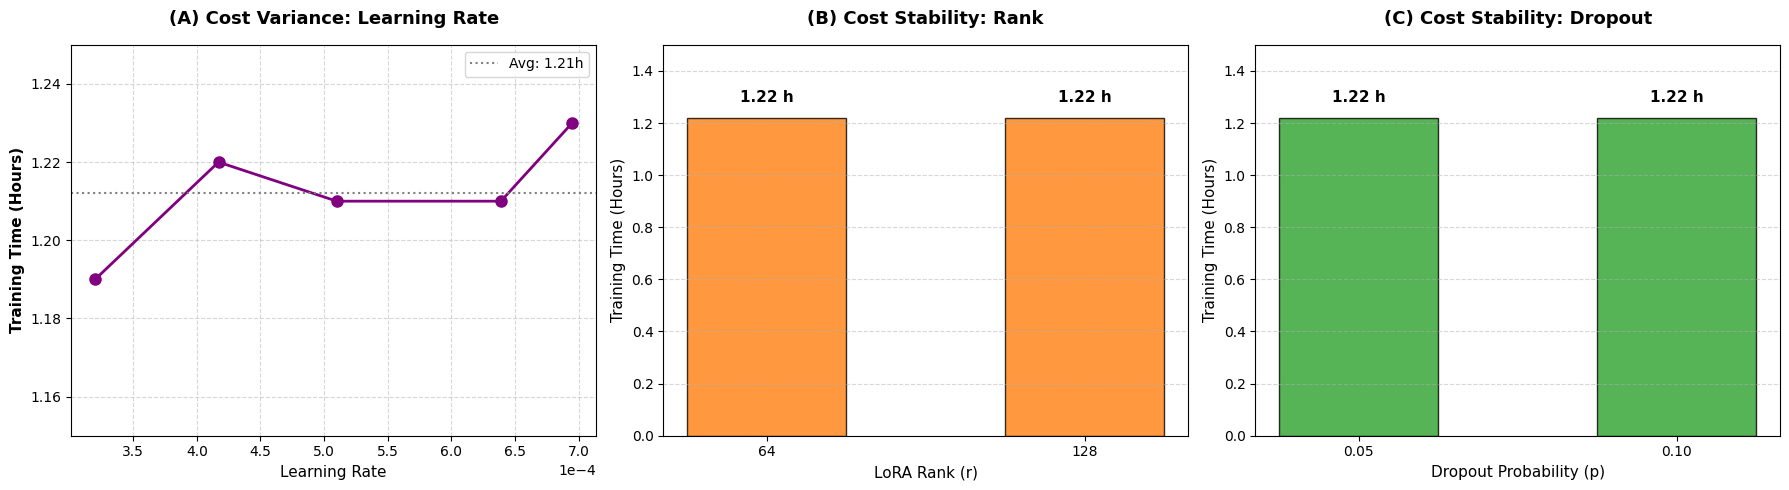

In [6]:
def plot_computational_cost():
    """
    Generates a 3-panel figure summarizing the Computational Cost (Time in Hours)
    for Learning Rate, Rank, and Dropout ablation studies.
    """

    # --- Data ---
    # Learning Rate Data
    lr_values = [3.20e-4, 4.17e-4, 5.10e-4, 6.39e-4, 6.95e-4]
    lr_time =   [1.19,    1.22,    1.21,    1.21,    1.23]

    # Rank Data
    rank_labels = ['64', '128']
    rank_time = [1.22, 1.22]

    # Dropout Data
    dropout_labels = ['0.05', '0.10']
    dropout_time = [1.22, 1.22]

    # --- Plotting Setup ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.3)

    # Global Style settings
    color_line = '#800080'   # Purple for LR
    color_rank = '#ff7f0e'   # Orange for Rank
    color_drop = '#2ca02c'   # Green for Dropout

    # ==========================================
    # Plot 1: Learning Rate vs Time (Line Plot)
    # ==========================================
    ax1 = axes[0]
    ax1.plot(lr_values, lr_time, marker='o', color=color_line, linewidth=2, markersize=8)

    ax1.set_xlabel('Learning Rate', fontsize=11)
    ax1.set_ylabel('Training Time (Hours)', fontsize=11, fontweight='bold')
    ax1.set_title('(A) Cost Variance: Learning Rate', fontsize=13, fontweight='bold', pad=15)

    # Format X-axis to scientific notation
    ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    # Zoom in slightly to show the noise/variance
    ax1.set_ylim(1.15, 1.25)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Annotate Mean Time
    mean_time = sum(lr_time) / len(lr_time)
    ax1.axhline(mean_time, color='gray', linestyle=':', label=f'Avg: {mean_time:.2f}h')
    ax1.legend()

    # ==========================================
    # Plot 2: Rank vs Time (Bar Chart)
    # ==========================================
    ax2 = axes[1]
    bars_rank = ax2.bar(rank_labels, rank_time, color=color_rank, width=0.5, alpha=0.8, edgecolor='black')

    ax2.set_xlabel('LoRA Rank (r)', fontsize=11)
    ax2.set_ylabel('Training Time (Hours)', fontsize=11)
    ax2.set_title('(B) Cost Stability: Rank', fontsize=13, fontweight='bold', pad=15)

    # Set Y-limit from 0 to show true scale
    ax2.set_ylim(0, 1.5)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Add labels
    for bar in bars_rank:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                 f'{height:.2f} h', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # ==========================================
    # Plot 3: Dropout vs Time (Bar Chart)
    # ==========================================
    ax3 = axes[2]
    bars_drop = ax3.bar(dropout_labels, dropout_time, color=color_drop, width=0.5, alpha=0.8, edgecolor='black')

    ax3.set_xlabel('Dropout Probability (p)', fontsize=11)
    ax3.set_ylabel('Training Time (Hours)', fontsize=11)
    ax3.set_title('(C) Cost Stability: Dropout', fontsize=13, fontweight='bold', pad=15)

    ax3.set_ylim(0, 1.5)
    ax3.grid(axis='y', linestyle='--', alpha=0.5)

    # Add labels
    for bar in bars_drop:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                 f'{height:.2f} h', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # --- Final Layout ---
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Research_Paper_Publication/plots/ablation_cost_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run
plot_computational_cost()

## Training vs Validation Loss Trajectories

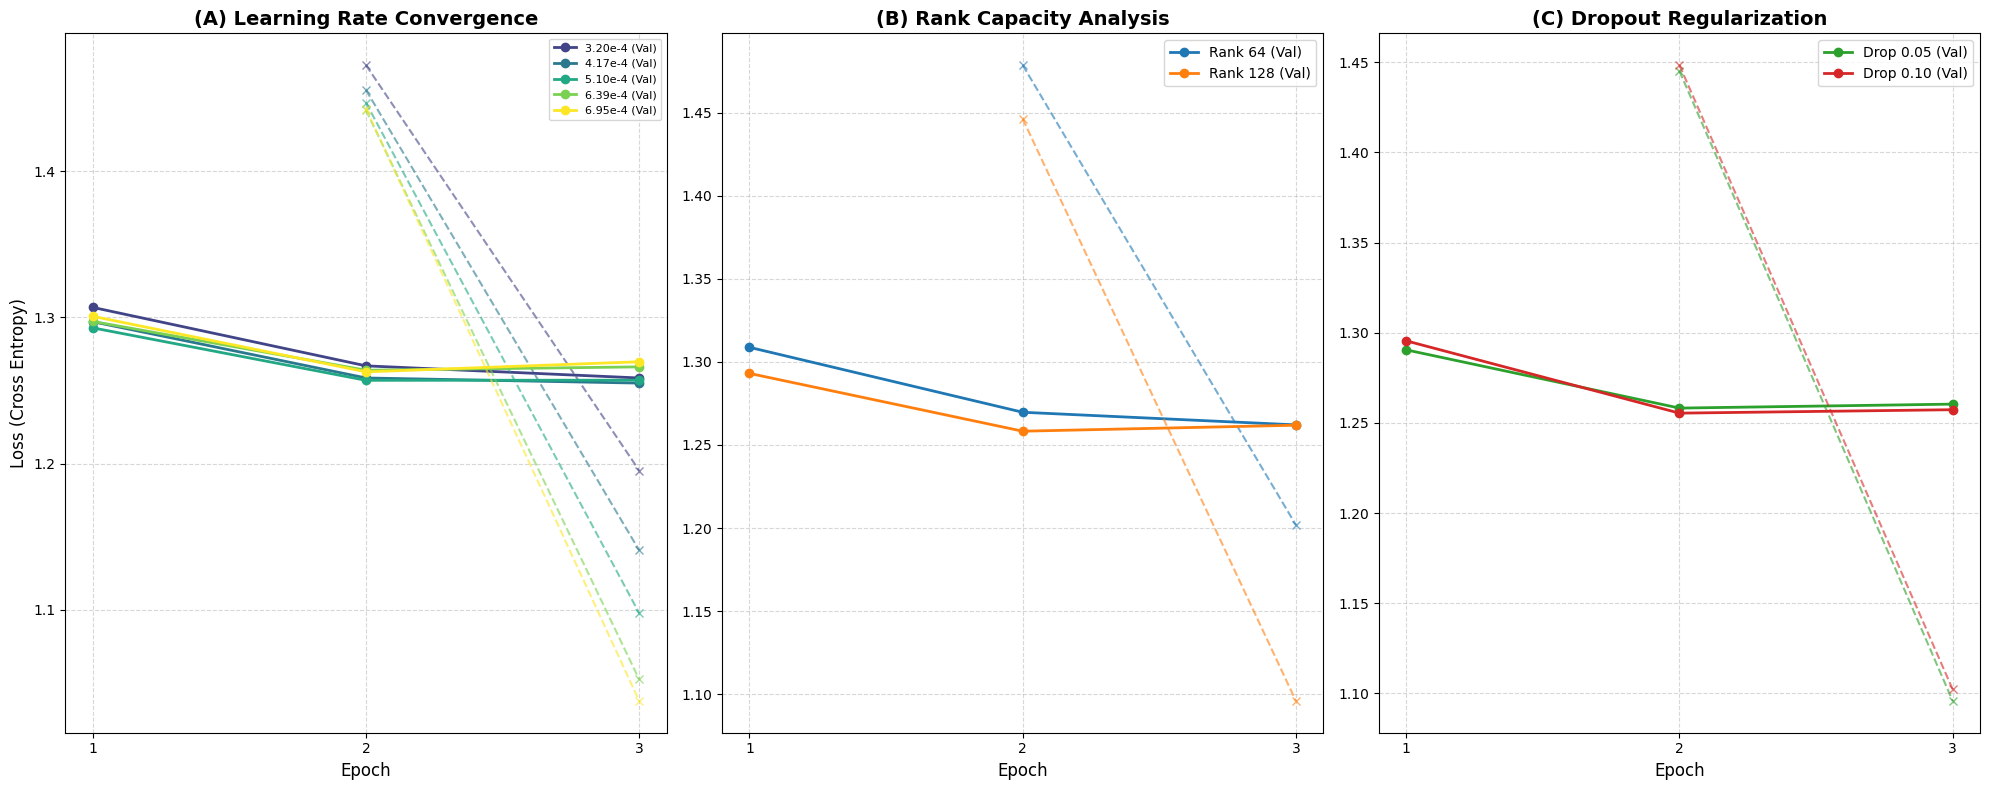

In [7]:
def plot_loss_curves():
    """
    Plots Training vs Validation Loss across epochs for Learning Rate, Rank, and Dropout ablations.
    Solid Lines: Represent Validation Loss.
    Dashed Lines: Represent Training Loss.
    """

    # --- Data Preparation ---
    epochs_val = [1, 2, 3]
    epochs_train = [2, 3] # Train loss missing for Epoch 1 in logs

    # 1. Learning Rate Data
    # Structure: 'Label': {'val': [ep1, ep2, ep3], 'train': [ep2, ep3]}
    lr_data = {
        "3.20e-4": {"val": [1.3069, 1.2669, 1.2586], "train": [1.4726, 1.1953]},
        "4.17e-4": {"val": [1.2971, 1.2586, 1.2551], "train": [1.4556, 1.1407]}, # Optimal
        "5.10e-4": {"val": [1.2929, 1.2570, 1.2571], "train": [1.4469, 1.0977]},
        "6.39e-4": {"val": [1.2973, 1.2639, 1.2662], "train": [1.4418, 1.0524]},
        "6.95e-4": {"val": [1.3008, 1.2628, 1.2697], "train": [1.4428, 1.0377]}
    }

    # 2. Rank Data
    rank_data = {
        "Rank 64":  {"val": [1.3088, 1.2697, 1.2621], "train": [1.4787, 1.2018]},
        "Rank 128": {"val": [1.2931, 1.2583, 1.2619], "train": [1.4463, 1.0959]}
    }

    # 3. Dropout Data
    dropout_data = {
        "Drop 0.05": {"val": [1.2905, 1.2582, 1.2604], "train": [1.4451, 1.0958]},
        "Drop 0.10": {"val": [1.2955, 1.2554, 1.2573], "train": [1.4484, 1.1022]}
    }

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    plt.subplots_adjust(wspace=0.25)

    # Helper to draw lines
    def draw_lines(ax, data_dict, cmap_name=None, color_list=None):
        if cmap_name:
            colors = plt.get_cmap(cmap_name)(np.linspace(0.2, 1.0, len(data_dict)))
        else:
            colors = color_list

        for i, (label, metrics) in enumerate(data_dict.items()):
            c = colors[i]
            # Solid line for Validation
            ax.plot(epochs_val, metrics["val"], label=f"{label} (Val)",
                    color=c, linestyle='-', marker='o', linewidth=2)
            # Dashed line for Training
            ax.plot(epochs_train, metrics["train"],
                    color=c, linestyle='--', marker='x', alpha=0.6)

    # Plot 1: Learning Rate (Sequential Colormap to show intensity)
    draw_lines(axes[0], lr_data, cmap_name="viridis")
    axes[0].set_title("(A) Learning Rate Convergence", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Loss (Cross Entropy)", fontsize=12)
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_xticks([1, 2, 3])
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(fontsize=8)

    # Plot 2: Rank
    draw_lines(axes[1], rank_data, color_list=['tab:blue', 'tab:orange'])
    axes[1].set_title("(B) Rank Capacity Analysis", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_xticks([1, 2, 3])
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    # Plot 3: Dropout
    draw_lines(axes[2], dropout_data, color_list=['tab:green', 'tab:red'])
    axes[2].set_title("(C) Dropout Regularization", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Epoch", fontsize=12)
    axes[2].set_xticks([1, 2, 3])
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Research_Paper_Publication/plots/ablation_loss_dynamics.png', dpi=300)
    plt.show()

plot_loss_curves()

## Combined ablation study & Efficiency tradeoff plots

Saved /content/drive/MyDrive/Research_Paper_Publication/plots/combined_ablation_study.pdf


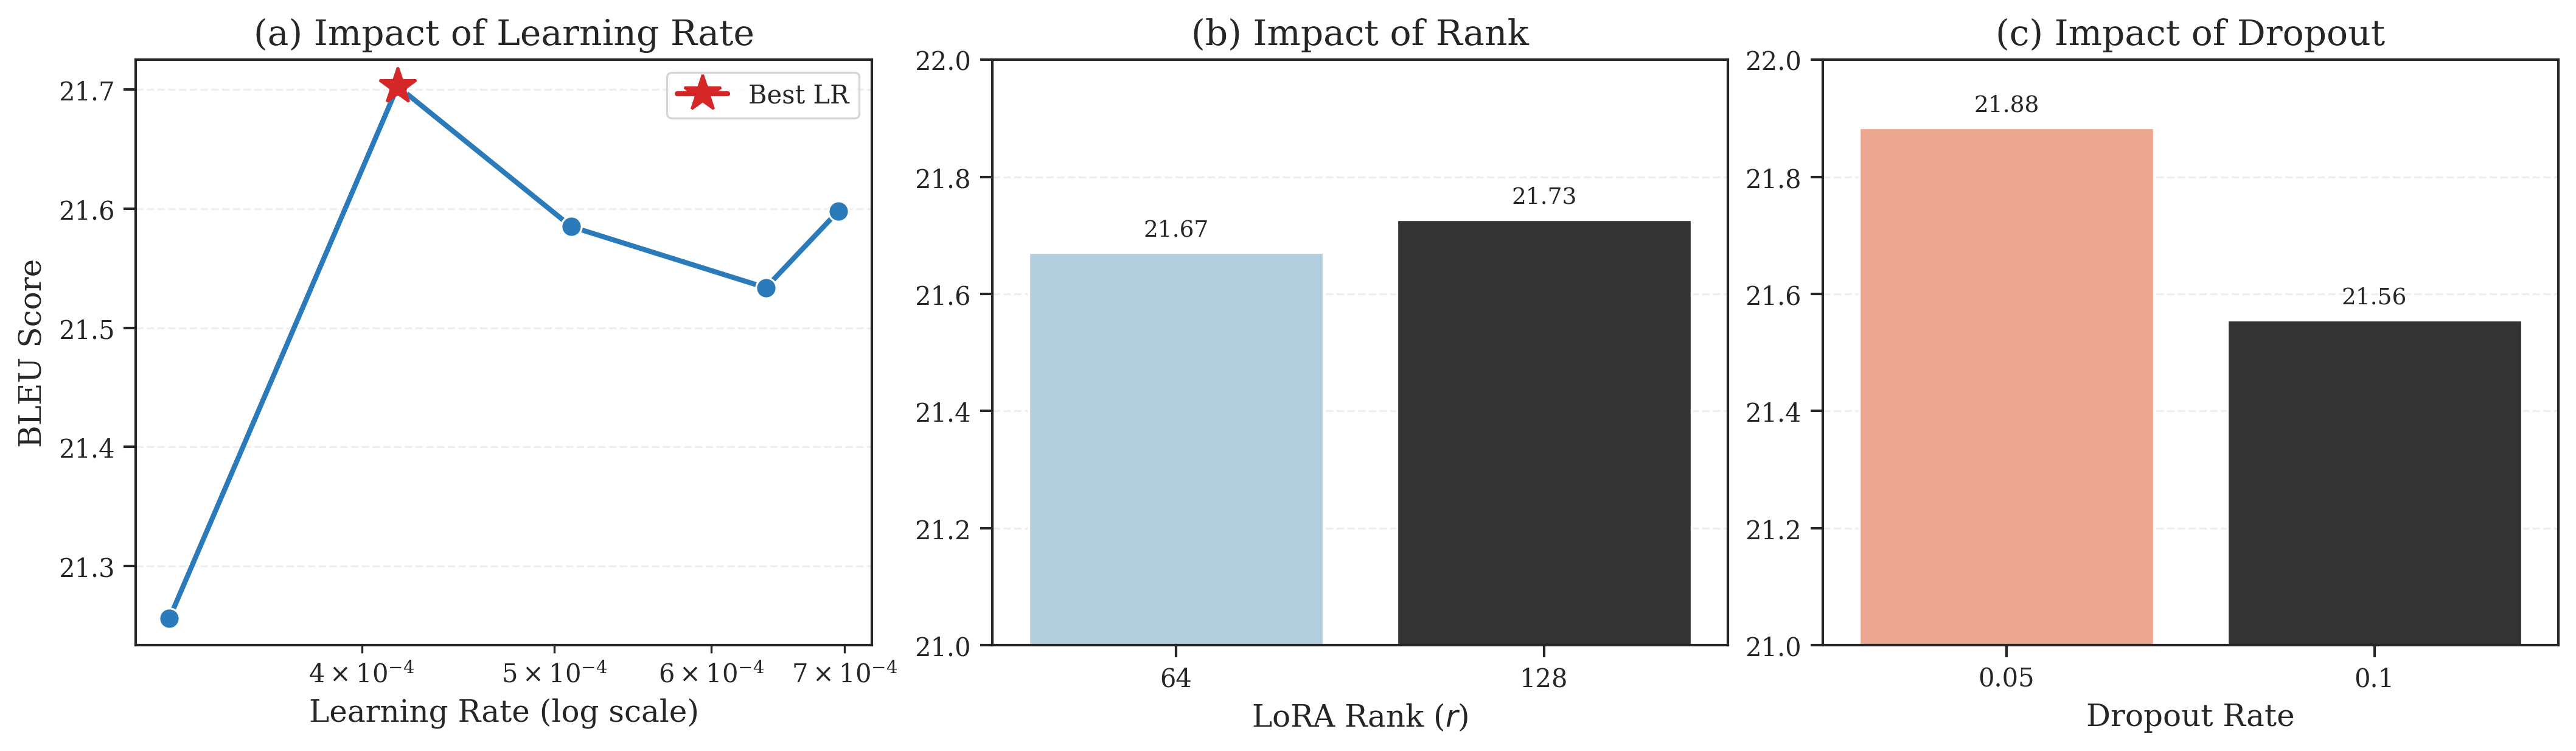

Saved /content/drive/MyDrive/Research_Paper_Publication/plots/efficiency_tradeoff.pdf


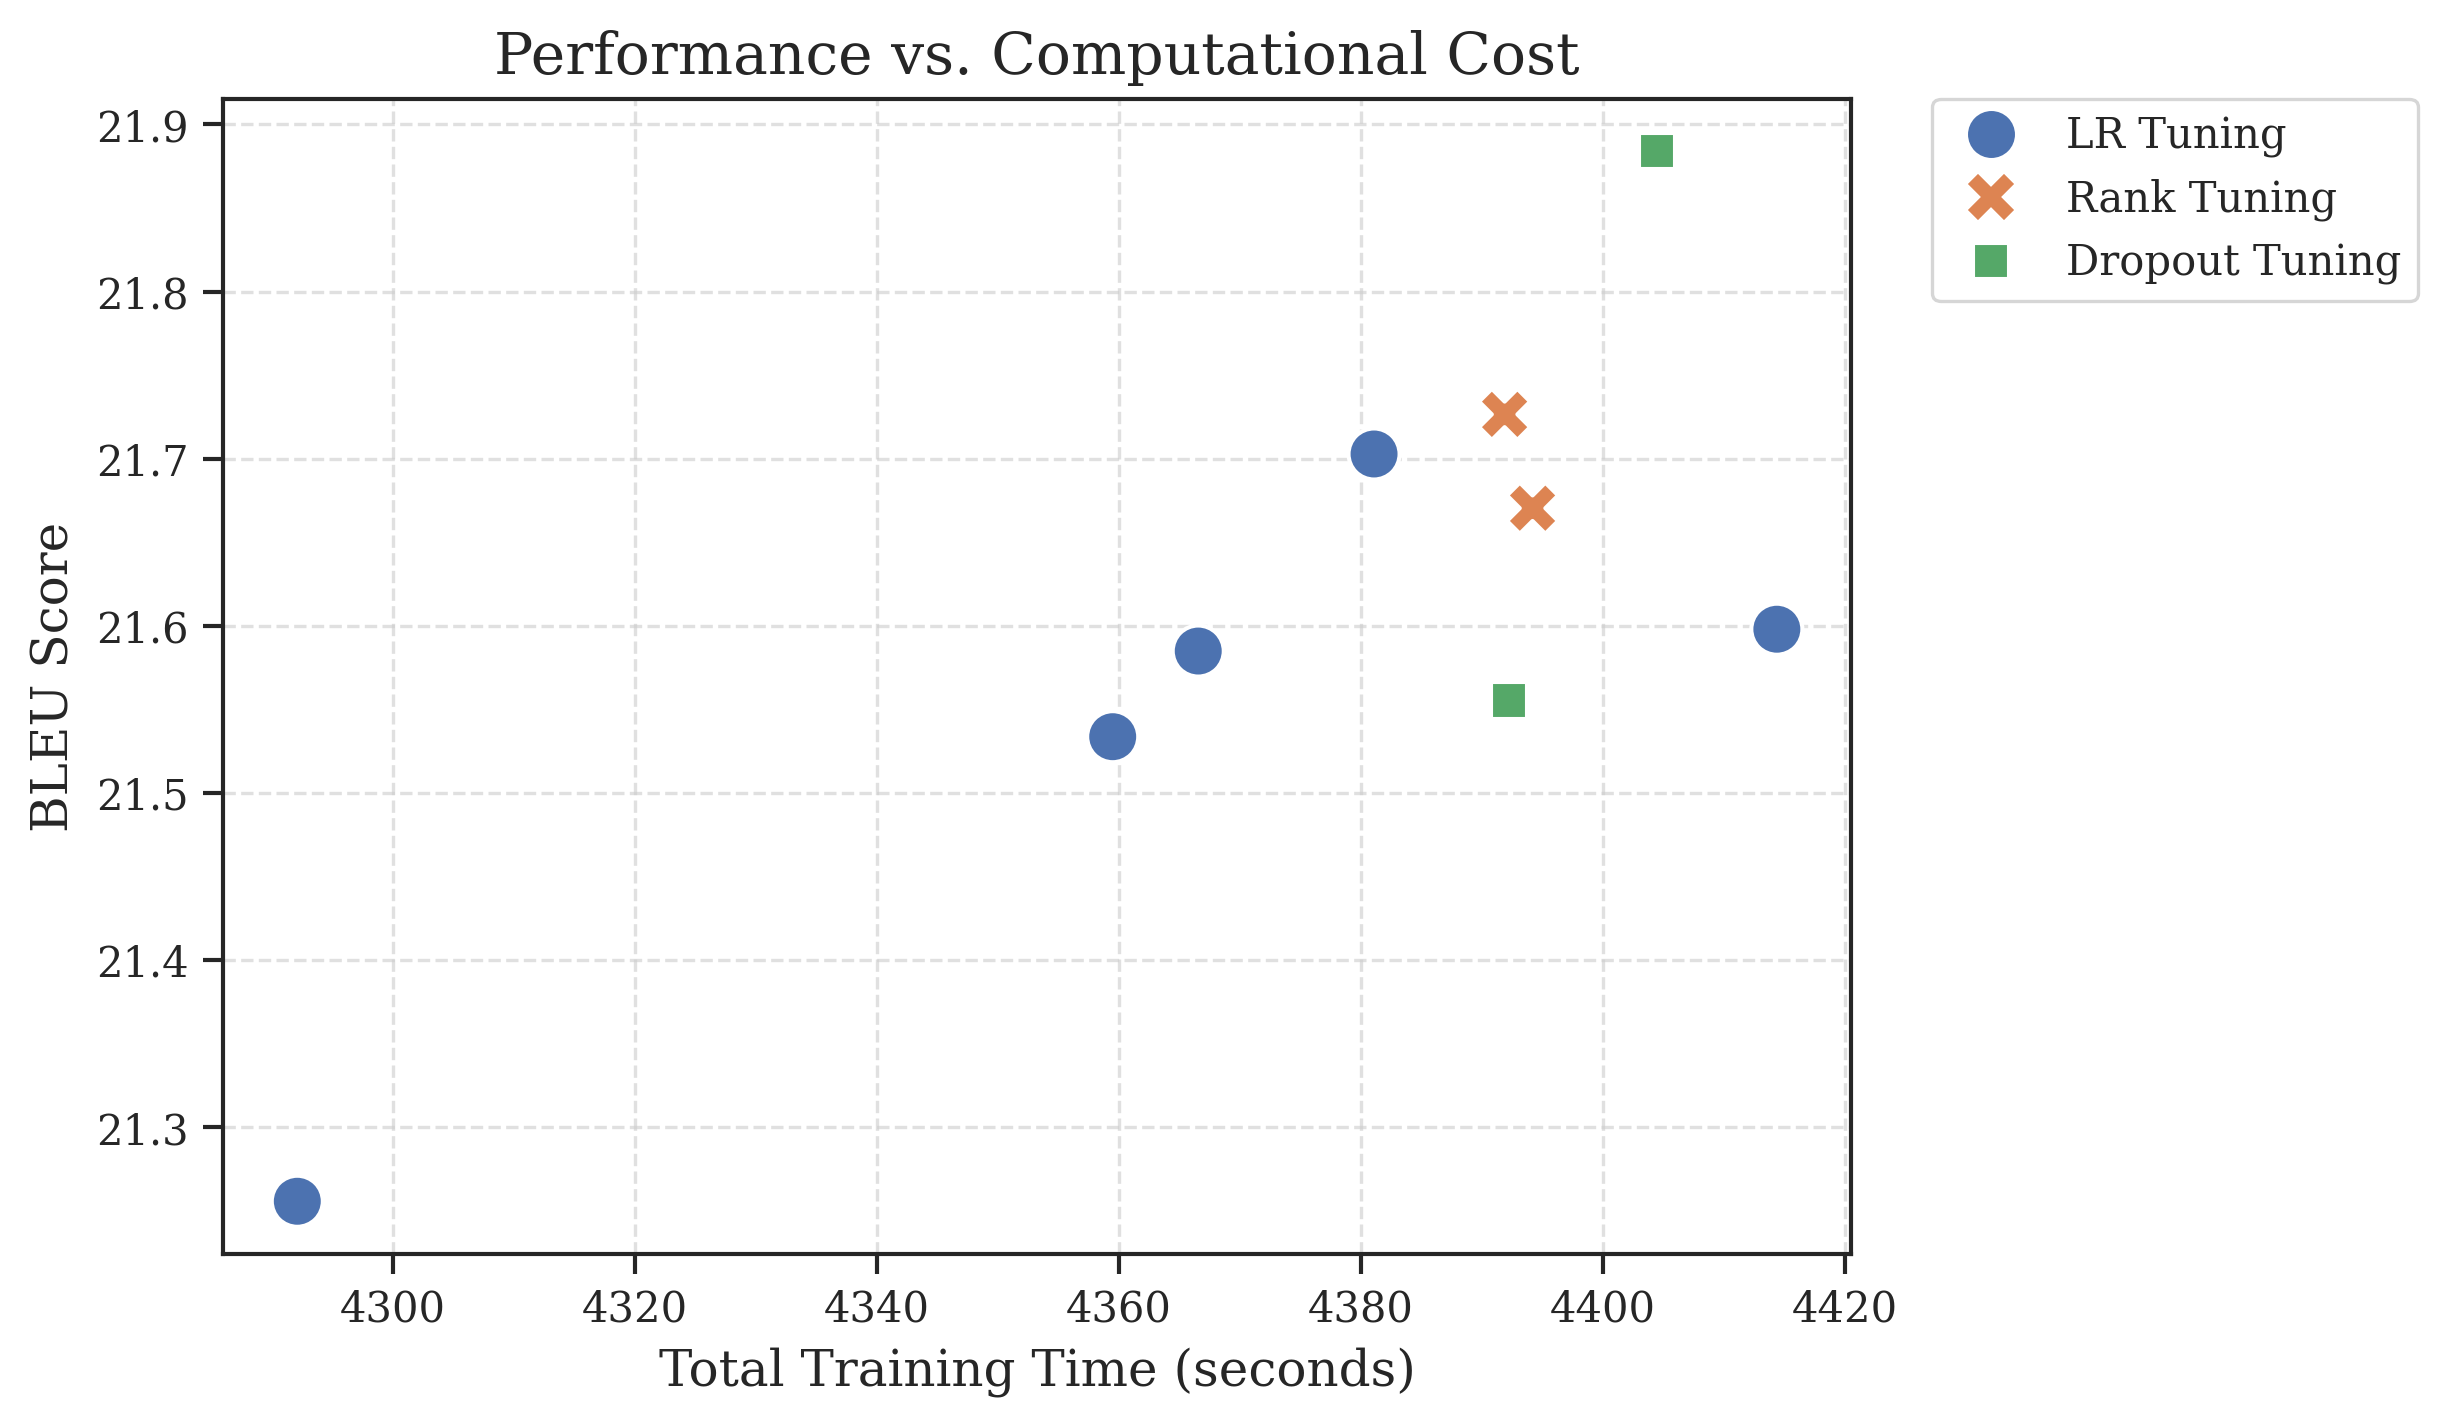

In [8]:
import seaborn as sns
import matplotlib.ticker as ticker

# --- 1. RECONSTRUCT DATA FROM YOUR OUTPUTS ---

# Data from df_lr output
data_lr = {
    "learning_rate": [0.000320, 0.000417, 0.000510, 0.000639, 0.000695],
    "bleu": [21.255729, 21.702827, 21.584924, 21.533682, 21.597981],
    "total_time_sec": [4292.08, 4381.07, 4366.54, 4359.47, 4414.36],
    "ablation_type": "Learning Rate"
}
df_lr = pd.DataFrame(data_lr)

# Data from df_rank output
data_rank = {
    "r": [64, 128],
    "bleu": [21.670394, 21.726525],
    "total_time_sec": [4394.17, 4391.86],
    "ablation_type": "Rank"
}
df_rank = pd.DataFrame(data_rank)

# Data from df_dropout output
data_dropout = {
    "dropout": [0.05, 0.10],
    "bleu": [21.883943, 21.555322],
    "total_time_sec": [4404.45, 4392.25],
    "ablation_type": "Dropout"
}
df_dropout = pd.DataFrame(data_dropout)

# --- 2. PUBLICATION STYLE CONFIGURATION ---

# Set a professional style (Serif font, white background, tick marks)
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"], # Fallback to DejaVu if Times not present
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300,        # High resolution for screen
    "savefig.dpi": 300,       # High resolution for export
    "lines.linewidth": 2,
    "lines.markersize": 8,
    "axes.grid": True,        # Turn on grid
    "grid.alpha": 0.3,        # Make grid subtle
    "grid.linestyle": "--",
})

# --- 3. GENERATE PLOTS ---

def plot_ablation_summary():
    """Generates a 1x3 multi-panel figure summarizing all ablations."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    # --- Panel A: Learning Rate (Line Plot) ---
    sns.lineplot(
        data=df_lr,
        x="learning_rate",
        y="bleu",
        marker="o",
        color="#2b7bba", # Professional Blue
        ax=axes[0]
    )

    # Highlight the max point
    best_lr = df_lr.loc[df_lr['bleu'].idxmax()]
    axes[0].plot(best_lr['learning_rate'], best_lr['bleu'], marker='*', color='#d62728', markersize=15, label='Best LR')

    axes[0].set_xscale("log")
    axes[0].set_xlabel("Learning Rate (log scale)")
    axes[0].set_ylabel("BLEU Score")
    axes[0].set_title("(a) Impact of Learning Rate")

    # Format x-ticks to be readable in log scale
    axes[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
    axes[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    axes[0].legend()

    # --- Panel B: LoRA Rank (Bar Plot) ---
    bp1 = sns.barplot(
        data=df_rank,
        x="r",
        y="bleu",
        hue="r",
        palette="Blues_d",
        ax=axes[1],
        legend=False
    )
    axes[1].set_xlabel("LoRA Rank ($r$)")
    axes[1].set_ylabel("") # Share Y label visually or keep it if scales differ widely
    axes[1].set_title("(b) Impact of Rank")
    axes[1].set_ylim(21.0, 22.0) # Zoom in to show difference

    # Add values on top of bars
    for p in bp1.patches:
        axes[1].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points',
                         fontsize=9)

    # --- Panel C: Dropout (Bar Plot) ---
    bp2 = sns.barplot(
        data=df_dropout,
        x="dropout",
        y="bleu",
        hue="dropout",
        palette="Reds_d",
        ax=axes[2],
        legend=False
    )
    axes[2].set_xlabel("Dropout Rate")
    axes[2].set_ylabel("")
    axes[2].set_title("(c) Impact of Dropout")
    axes[2].set_ylim(21.0, 22.0) # Consistent zoom

    # Add values on top of bars
    for p in bp2.patches:
        axes[2].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points',
                         fontsize=9)

    # Save
    filename = "/content/drive/MyDrive/Research_Paper_Publication/plots/combined_ablation_study.pdf"
    plt.savefig(filename, bbox_inches='tight')
    print(f"Saved {filename}")
    plt.show()

def plot_efficiency_tradeoff():
    """Generates a scatter plot of BLEU vs Training Time."""
    # Combine data
    df_all = pd.concat([
        df_lr.assign(Experiment="LR Tuning"),
        df_rank.assign(Experiment="Rank Tuning"),
        df_dropout.assign(Experiment="Dropout Tuning")
    ])

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df_all,
        x="total_time_sec",
        y="bleu",
        hue="Experiment",
        style="Experiment",
        s=150, # Marker size
        palette="deep"
    )

    plt.xlabel("Total Training Time (seconds)")
    plt.ylabel("BLEU Score")
    plt.title("Performance vs. Computational Cost")

    # Add grid and legend
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    filename = "/content/drive/MyDrive/Research_Paper_Publication/plots/efficiency_tradeoff.pdf"
    plt.savefig(filename, bbox_inches='tight')
    print(f"Saved {filename}")
    plt.show()

# --- 4. EXECUTE ---
plot_ablation_summary()
plot_efficiency_tradeoff()